# ColourBomb product MDP / DFA demo

This demo supports the tutorial section immediately after the **product MDP** construction.

The goals are:

1. define a DFA for a safety property over ColourBombGridWorld labels;
2. wrap the environment with MASA's LTL-safety/product-state wrapper through `make_env`;
3. step through the augmented MDP while observing original labels, DFA/product state, and costs.

The demo uses the “diffuse bombs” property as a bad-prefix monitor. The proposition names in the environment are `bomb` and `medic`, so the monitor treats `medic` as the “diffused / recovered” proposition.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import inspect
import textwrap
import warnings
import pprint

# Make the notebook runnable when dropped into MASA-Safe-RL/tutorial/ or opened from repo root.
HERE = Path.cwd().resolve()
REPO_ROOT = None
for candidate in [HERE, *HERE.parents]:
    if (candidate / "masa").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError(
        "Could not find a parent directory containing the `masa/` package. "
        "Open this notebook from within the MASA-Safe-RL repository, or install MASA with `pip install -e .`."
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"Using MASA source tree: {REPO_ROOT}")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Importing masa.envs registers environments with MASA's registry.
import masa.envs  # noqa: F401
import masa.common.constraints  # noqa: F401
from masa.common.utils import make_env


def show_source(obj, title: str | None = None, fallback: str | None = None):
    """Display Python source for a function/class in a Markdown code block."""
    if title:
        display(Markdown(f"**{title}**"))
    try:
        src = inspect.getsource(obj)
    except Exception as exc:
        src = fallback or f"# Source unavailable for {obj!r}: {exc}"
    display(Markdown("```python\n" + textwrap.dedent(src).strip() + "\n```"))


def unwrap_chain(env, limit: int = 30):
    cur = env
    seen = []
    for _ in range(limit):
        seen.append(cur)
        nxt = getattr(cur, "env", None)
        if nxt is None or nxt is cur:
            break
        cur = nxt
    return seen


def render_frame(env):
    """Render the first usable RGB frame found while unwrapping env wrappers."""
    for cur in unwrap_chain(env):
        try:
            frame = cur.render()
            if frame is not None and not isinstance(frame, str):
                return frame
        except Exception:
            pass
    return None


def show_frames(frames, titles=None, max_cols: int = 4):
    frames = [f for f in frames if f is not None]
    if not frames:
        print("No RGB frames were captured. Try creating the env with render_mode='rgb_array'.")
        return
    n = len(frames)
    cols = min(max_cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(frames[i])
            if titles and i < len(titles):
                ax.set_title(str(titles[i]))
    plt.tight_layout()
    plt.show()


def nested_get(d, *keys, default=None):
    cur = d
    for key in keys:
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def compact_info(info):
    """Return a compact dict with the most useful MASA wrapper signals."""
    out = {}
    for key in ["labels", "label", "constraint", "reward", "automaton_state", "margin_penalty", "proj_penalty"]:
        if isinstance(info, dict) and key in info:
            out[key] = info[key]
    step = nested_get(info, "constraint", "step", default=None)
    episode = nested_get(info, "constraint", "episode", default=None)
    if step is not None:
        out["constraint.step"] = step
    if episode is not None:
        out["constraint.episode"] = episode
    return out

Using MASA source tree: /mnt/c/Users/alexw/OneDrive/Imperial/MASA-Safe-RL


In [2]:
from masa.envs.tabular import colour_bomb_grid_world as cb
from masa.envs.tabular.colour_bomb_grid_world import ColourBombGridWorld, label_fn as colour_label_fn
from masa.common.ltl import DFA, Atom, Neg, And, Or, Truth

show_source(colour_label_fn, "ColourBombGridWorld `label_fn`")
print("Bomb states:", cb.BOMB_STATES)
print("Goal states:", cb.GOAL_STATES)

**ColourBombGridWorld `label_fn`**

```python
label_fn = lambda obs: LABEL_DICT[obs]
```

Bomb states: [27, 43, 78]
Goal states: [70, 79, 9, 10, 18, 19, 7, 8, 16, 17]


## DFA definition

For a live tutorial, the exact slide formula can be written as the temporal rule. The code below implements the corresponding monitor as a DFA:

- state `0`: no active obligation;
- state `1`: a bomb was seen and must be diffused/recovered on the next step;
- state `2`: bad absorbing state.

Accepting states are interpreted as **bad** states by MASA's DFA cost wrapper.

In [3]:
def make_diffuse_bombs_dfa() -> DFA:
    """DFA monitor for: after a `bomb` label, the next label must contain `medic`.

    MASA's DFA edge guards are propositional formulae over the label set at the current time.
    Accepting states are violations / bad states.
    """
    bomb = Atom("bomb")
    no_bomb = Neg(bomb)

    dfa = DFA(states=[0, 1, 2], initial=0, accepting=[2])

    # From q0, seeing a bomb creates a one-step obligation to diffuse the bomb.
    dfa.add_edge(0, 1, bomb)
    dfa.add_edge(0, 0, no_bomb)

    # From q1, staying at the bomb state diffuses the bomb; leaving results in a violation.
    dfa.add_edge(1, 0, bomb)
    dfa.add_edge(1, 2, no_bomb)

    # Bad state is absorbing.
    dfa.add_edge(2, 2, Truth())
    return dfa

dfa = make_diffuse_bombs_dfa()
show_source(make_diffuse_bombs_dfa, "DFA constructor used in this notebook")
print("DFA states:", dfa.states)
print("DFA initial:", dfa.initial)
print("DFA accepting/bad states:", dfa.accepting)
print("DFA edges:")
pprint.pp(dfa.edges)

**DFA constructor used in this notebook**

```python
def make_diffuse_bombs_dfa() -> DFA:
    """DFA monitor for: after a `bomb` label, the next label must contain `medic`.

    MASA's DFA edge guards are propositional formulae over the label set at the current time.
    Accepting states are violations / bad states.
    """
    bomb = Atom("bomb")
    no_bomb = Neg(bomb)

    dfa = DFA(states=[0, 1, 2], initial=0, accepting=[2])

    # From q0, seeing a bomb creates a one-step obligation to diffuse the bomb.
    dfa.add_edge(0, 1, bomb)
    dfa.add_edge(0, 0, no_bomb)

    # From q1, staying at the bomb state diffuses the bomb; leaving results in a violation.
    dfa.add_edge(1, 0, bomb)
    dfa.add_edge(1, 2, no_bomb)

    # Bad state is absorbing.
    dfa.add_edge(2, 2, Truth())
    return dfa
```

DFA states: [0, 1, 2]
DFA initial: 0
DFA accepting/bad states: [2]
DFA edges:
{0: {1: <masa.common.ltl.Atom object at 0x722631d29f90>,
     0: <masa.common.ltl.Neg object at 0x722631d282b0>},
 1: {0: <masa.common.ltl.Atom object at 0x722631d29f90>,
     2: <masa.common.ltl.Neg object at 0x722631d282b0>},
 2: {2: <masa.common.ltl.Truth object at 0x722631d40c70>}}


Initial augmented/product observation: 74
Observation space: Discrete(243)
Action space: Discrete(5)
{'labels': {'start'},
 'constraint': {'type': 'LTL_SAFETY', 'step': {'cost': 0.0, 'violation': 0.0}},
 'automaton_state': 0,
 'constraint.step': {'cost': 0.0, 'violation': 0.0}}


/home/sacktock/anaconda3/envs/masa/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


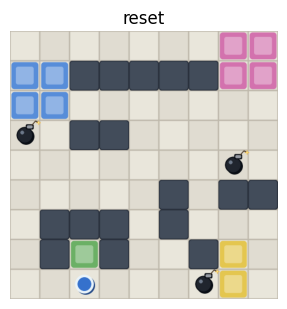

In [4]:
# The LTL/DFA constraint wrapper constructs a product between the environment state and the DFA monitor state.
# If your local MASA branch uses a different constraint id, edit `constraint_id` here.
constraint_id = "LTL_SAFETY"

def make_colour_bomb_ltl_env(max_episode_steps: int = 40, seed: int = 0):
    env = make_env(
        "ColourBombGridWorld",
        constraint_id,
        max_episode_steps,
        label_fn=colour_label_fn,
        constraint_kwargs={"dfa": make_diffuse_bombs_dfa()},
        env_kwargs={"render_mode": "rgb_array"},
    )
    obs, info = env.reset(seed=seed)
    return env, obs, info

env, obs, info = make_colour_bomb_ltl_env(seed=4)
print("Initial augmented/product observation:", obs)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
pprint.pp(compact_info(info))
show_frames([render_frame(env)], ["reset"])

{'t': 1,
 'action': 1,
 'product_obs': {'product_obs': 75},
 'reward': 0.0,
 'terminated': False,
 'truncated': False,
 'compact_info': {'labels': set(),
                  'constraint': {'type': 'LTL_SAFETY', 'step': {'cost': 0.0, 'violation': 0.0}},
                  'automaton_state': 0,
                  'constraint.step': {'cost': 0.0, 'violation': 0.0}}}
------------------------------------------------------------------------------------------------------------------------
{'t': 2,
 'action': 1,
 'product_obs': {'product_obs': 76},
 'reward': 0.0,
 'terminated': False,
 'truncated': False,
 'compact_info': {'labels': set(),
                  'constraint': {'type': 'LTL_SAFETY', 'step': {'cost': 0.0, 'violation': 0.0}},
                  'automaton_state': 0,
                  'constraint.step': {'cost': 0.0, 'violation': 0.0}}}
------------------------------------------------------------------------------------------------------------------------
{'t': 3,
 'action': 1,
 'product_o

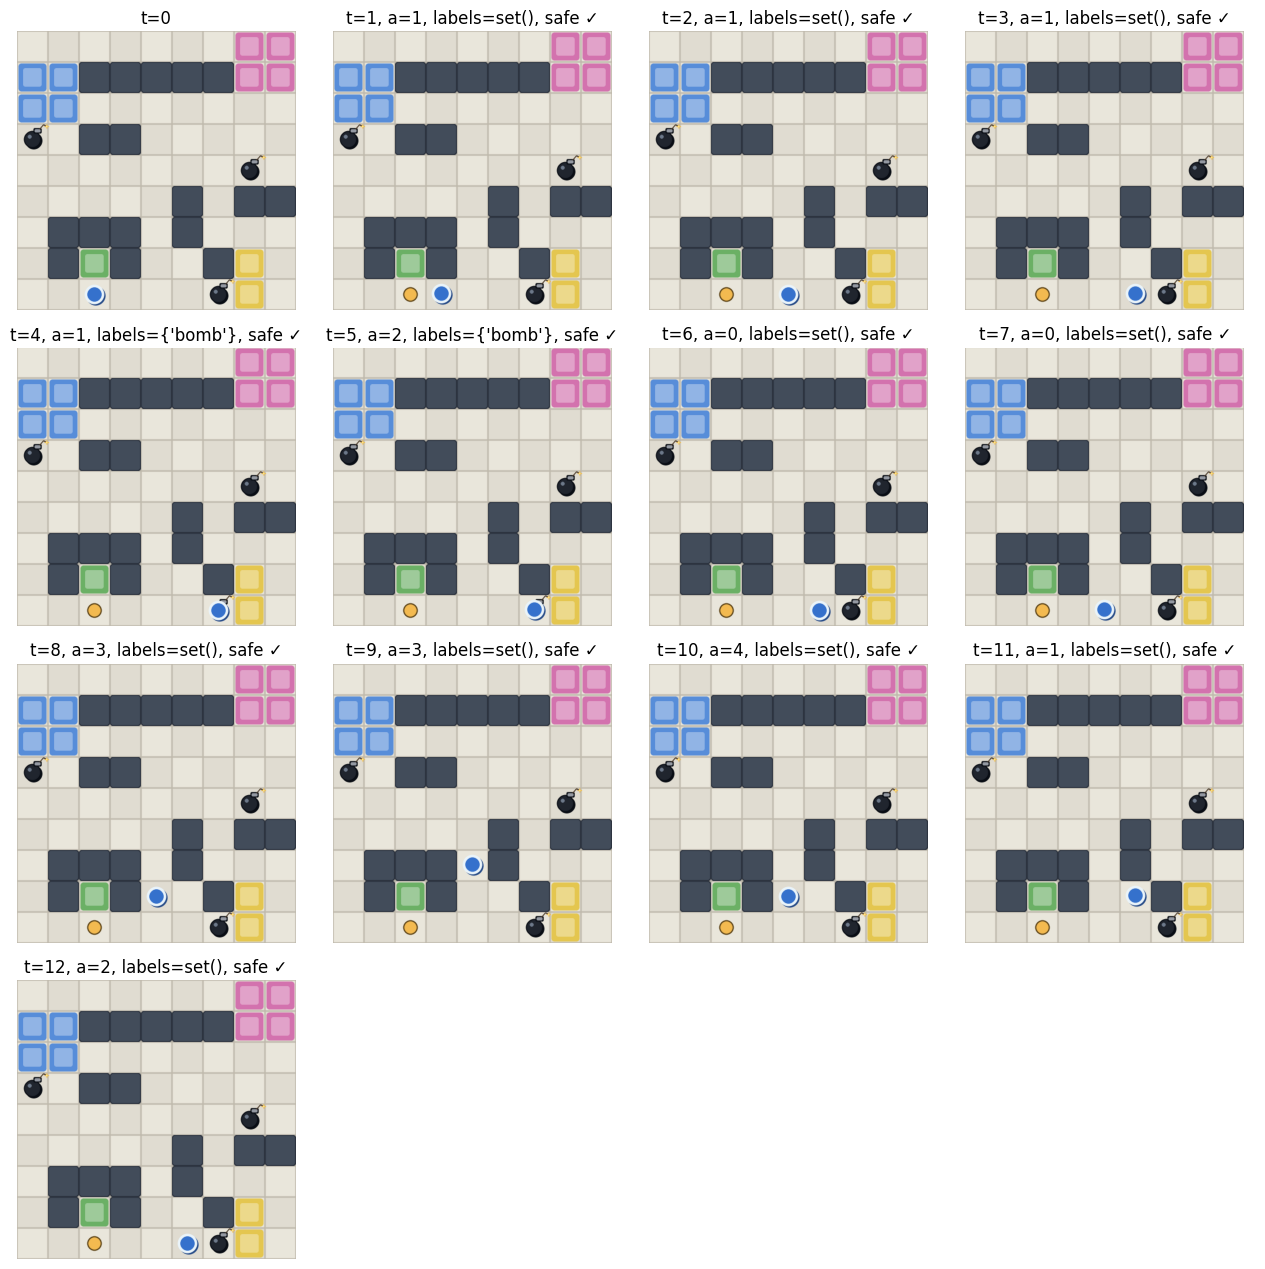

In [8]:
def describe_product_obs(obs):
    """Best-effort description of product observations across MASA branches."""
    if isinstance(obs, tuple) and len(obs) == 2:
        return {"env_state": obs[0], "dfa_state": obs[1]}
    if isinstance(obs, dict):
        return {k: v for k, v in obs.items()}
    return {"product_obs": obs}

# Scripted actions; change these to deliberately enter a bomb then recover via a medic.
action_script = [1, 1, 1, 1, 2, 0, 0, 3, 3, 4, 1, 2]
frames, titles, rows = [], [], []
obs, info = env.reset(seed=5)
frames.append(render_frame(env))
titles.append("t=0")

for t, action in enumerate(action_script, start=1):
    next_obs, reward, terminated, truncated, info = env.step(action)
    row = {
        "t": t,
        "action": action,
        "product_obs": describe_product_obs(next_obs),
        "reward": float(reward),
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "compact_info": compact_info(info),
    }
    rows.append(row)
    labels = nested_get(info, "labels", default=None)
    frames.append(render_frame(env))
    titles.append(f"t={t}, a={action}, labels={labels}, safe {'✓' if not compact_info(info)['constraint.step']['violation'] else 'X'}")
    obs = next_obs
    if terminated or truncated:
        break

for row in rows:
    pprint.pp(row, width=140)
    print("-" * 120)

show_frames(frames, titles)

**Talking point.** The product state stores enough history to evaluate a temporal safety property by ordinary state-based reachability: reaching an accepting DFA state means that a bad prefix has occurred.